# Hybrid Product Recommendation System
### An Educational Guide to Building Modern Recommender Systems

Welcome to the **Hybrid Product Recommendation System** notebook. This notebook is designed as a beginner-friendly, step-by-step tutorial to build, train, evaluate, and save a hybrid recommendation engine.

#### **Objectives**:
1. **Content-Based Filtering**: Recommend items similar to what a user liked based on product metadata (TF-IDF + Cosine Similarity).
2. **Collaborative Filtering**: Predict ratings for unrated products based on historical patterns of similar users (SVD Matrix Factorization).
3. **Hybrid Model**: Integrate both techniques dynamically to deliver highly accurate, personalized, and cold-start-resilient recommendations.

--- 
## 1. Import Libraries
We start by importing standard data science, machine learning, and visualization libraries. We'll use custom SVD implementation (NumPy/Pandas) to avoid library compiler issues on Windows, but the logic is identical to industry standards.

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import joblib

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


--- 
## 2. Load the Dataset
Let's load the generated datasets from our `data/` directory. If they don't exist yet, we'll verify the data generator has populated the project.

In [2]:
# File paths
PRODUCTS_PATH = "data/products.csv"
USERS_PATH = "data/users.csv"
RATINGS_PATH = "data/ratings.csv"

# Load datasets using Pandas
products_df = pd.read_csv(PRODUCTS_PATH)
users_df = pd.read_csv(USERS_PATH)
ratings_df = pd.read_csv(RATINGS_PATH)

# Display metadata details
print(f"Products shape: {products_df.shape}")
print(f"Users shape: {users_df.shape}")
print(f"Ratings shape: {ratings_df.shape}")

Products shape: (80, 8)
Users shape: (150, 4)
Ratings shape: (2911, 3)


In [3]:
# Inspect products dataset
products_df.head(3)

,Product ID,Product Name,Brand,Category,Description,Price,Rating,Image Path
0,P001,iPhone 15 Pro,Apple,Electronics,Flagship titanium smartphone with advanced cam...,100500,4.6,static/images/products/electronics_cat.jpg
1,P002,Galaxy S24 Ultra,Samsung,Electronics,Premium Android smartphone with integrated S-P...,95800,3.8,static/images/products/electronics_cat.jpg
2,P003,WH-1000XM5 Headphones,Sony,Electronics,Industry-leading active noise-canceling wirele...,45200,4.7,static/images/products/electronics_cat.jpg


In [4]:
# Inspect users dataset
users_df.head(3)

,User ID,Age,Gender,Location
0,1,26,Male,"San Jose, CA"
1,2,33,Female,"Boston, MA"
2,3,62,Male,"Denver, CO"


In [5]:
# Inspect ratings dataset
ratings_df.head(3)

,User ID,Product ID,Rating
0,1,P039,1
1,1,P002,5
2,1,P020,3


--- 
## 3. Data Cleaning and Preprocessing
Before analysis, we check for missing values or duplicates to ensure our recommendation outputs are completely clean.

In [ ]:
# Check for null values in each dataset
print("Missing values in Products:", products_df.isnull().sum())
print("Missing values in Users:", users_df.isnull().sum())
print("Missing values in Ratings:", ratings_df.isnull().sum())

Missing values in Products:
 Product ID      0
Product Name    0
Brand           0
Category        0
Description     0
Price           0
Rating          0
Image Path      0
dtype: int64

Missing values in Users:
 User ID     0
Age         0
Gender      0
Location    0
dtype: int64

Missing values in Ratings:
 User ID       0
Product ID    0
Rating        0
dtype: int64


In [7]:
# Check for duplicate rows
print(f"Duplicate rows in ratings: {ratings_df.duplicated(subset=['User ID', 'Product ID']).sum()}")

Duplicate rows in ratings: 0


--- 
## 4. Exploratory Data Analysis (EDA) & Visualizations
Let's explore our dataset distribution and save beautiful chart images inside `static/images/visualizations/` so that we can render them later on our dashboard.

In [8]:
# Ensure the visualization directory exists
vis_dir = "static/images/visualizations"
os.makedirs(vis_dir, exist_ok=True)
print(f"Visualizations will be saved to: {vis_dir}")

Visualizations will be saved to: static/images/visualizations


C:\Users\krish\AppData\Local\Temp\ipykernel_10440\2030687960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Rating", data=ratings_df, palette="viridis")


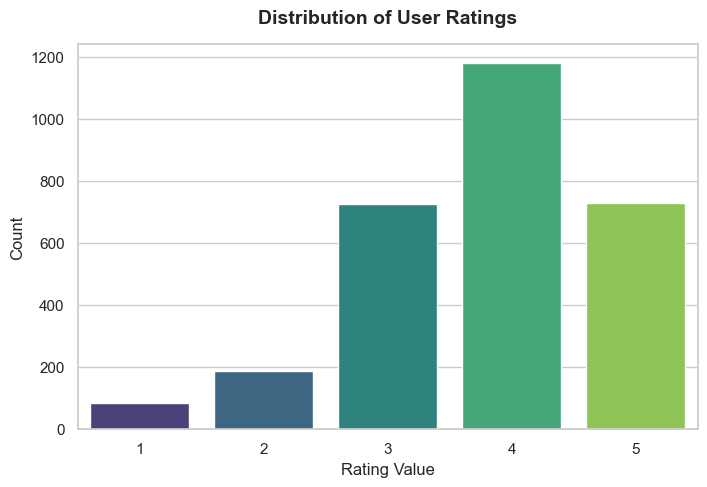

In [9]:
# 1. Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="Rating", data=ratings_df, palette="viridis")
plt.title("Distribution of User Ratings", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rating Value", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig(os.path.join(vis_dir, "rating_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_10440\3614735773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Category", data=products_df, palette="magma", order=products_df["Category"].value_counts().index)


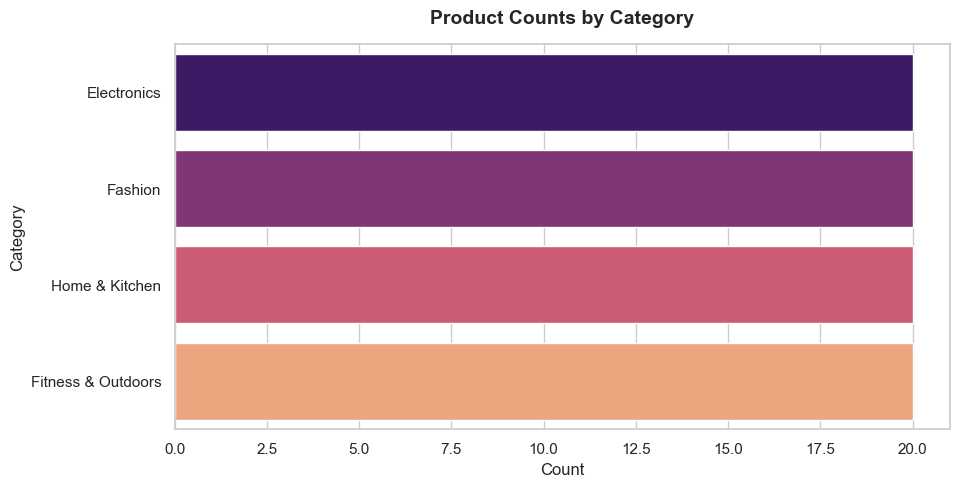

In [10]:
# 2. Category Distribution
plt.figure(figsize=(10, 5))
sns.countplot(y="Category", data=products_df, palette="magma", order=products_df["Category"].value_counts().index)
plt.title("Product Counts by Category", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.savefig(os.path.join(vis_dir, "category_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_10440\2418285357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="plasma")


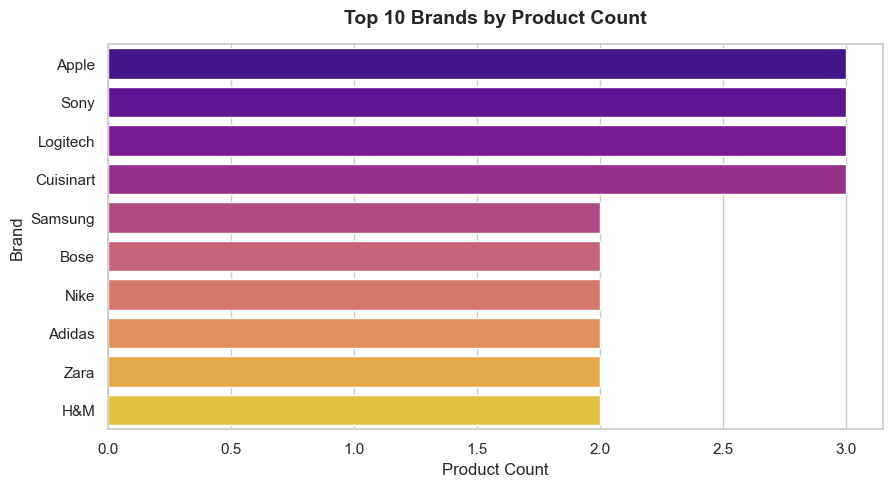

In [11]:
# 3. Brand Distribution (Top 10 most popular brands)
plt.figure(figsize=(10, 5))
top_brands = products_df["Brand"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="plasma")
plt.title("Top 10 Brands by Product Count", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Product Count", fontsize=12)
plt.ylabel("Brand", fontsize=12)
plt.savefig(os.path.join(vis_dir, "brand_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_10440\4035628920.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Rating Count", y="Product Name", data=popular_products, palette="rocket")


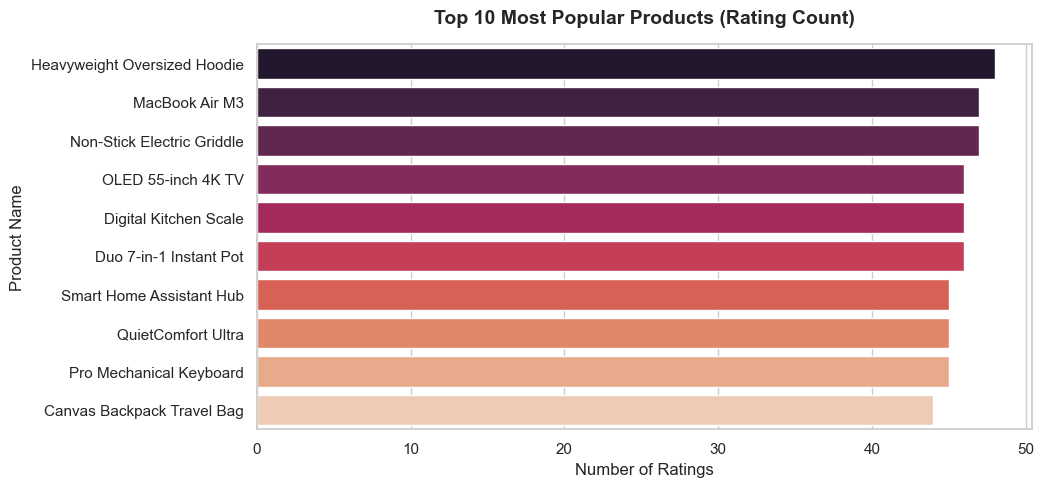

In [12]:
# 4. Most Popular Products (Highest number of ratings)
plt.figure(figsize=(10, 5))
popular_products = ratings_df["Product ID"].value_counts().head(10).reset_index()
popular_products.columns = ["Product ID", "Rating Count"]
popular_products = popular_products.merge(products_df[["Product ID", "Product Name"]], on="Product ID")
sns.barplot(x="Rating Count", y="Product Name", data=popular_products, palette="rocket")
plt.title("Top 10 Most Popular Products (Rating Count)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Ratings", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.savefig(os.path.join(vis_dir, "popular_products.png"), dpi=300, bbox_inches='tight')
plt.show()

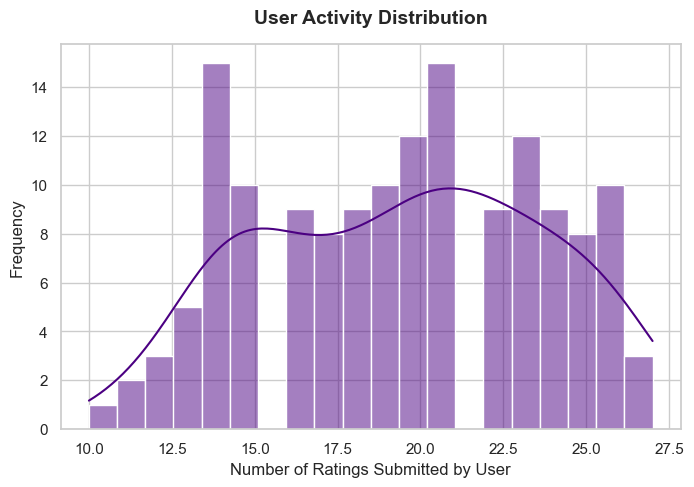

In [13]:
# 5. User Activity (Number of ratings per user)
plt.figure(figsize=(8, 5))
user_counts = ratings_df.groupby("User ID").size()
sns.histplot(user_counts, kde=True, color="indigo", bins=20)
plt.title("User Activity Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Ratings Submitted by User", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.savefig(os.path.join(vis_dir, "user_activity.png"), dpi=300, bbox_inches='tight')
plt.show()

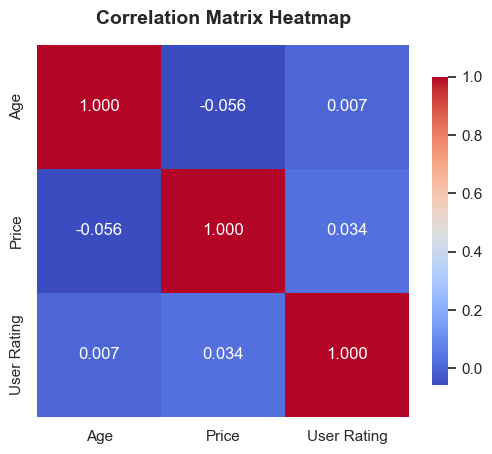

In [14]:
# 6. Correlation Heatmap between Numerical Features
# Merge users and ratings first
merged_df = ratings_df.merge(users_df, on="User ID").merge(products_df, on="Product ID")
correlation_data = merged_df[["Age", "Price", "Rating_x"]].rename(columns={"Rating_x": "User Rating"})

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_data.corr(), annot=True, cmap="coolwarm", fmt=".3f", square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.savefig(os.path.join(vis_dir, "correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

--- 
## 5. Content-Based Filtering (TF-IDF & Cosine Similarity)
Content-based recommenders use descriptive metadata text to recommend items similar to what a user is currently looking at. Here we combine title, brand, category, and descriptions into a metadata text "soup".

In [15]:
# Prepare metadata soup
products_df['metadata_soup'] = (
    products_df['Product Name'] + " " +
    products_df['Brand'] + " " +
    products_df['Category'] + " " +
    products_df['Description']
)

# Fit TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(stop_words='english')
tfidf_mat = tfidf_vec.fit_transform(products_df['metadata_soup'])

print(f"TF-IDF Matrix shape: {tfidf_mat.shape}")
# Note: {tfidf_mat.shape[1]} distinct features have been learned!

TF-IDF Matrix shape: (80, 893)


In [16]:
# Calculate Cosine Similarity
cosine_sim_matrix = cosine_similarity(tfidf_mat, tfidf_mat)
print(f"Cosine Similarity Matrix shape: {cosine_sim_matrix.shape}")

Cosine Similarity Matrix shape: (80, 80)


In [17]:
# Helper function to recommend top N similar products
def get_similar_items(product_id, top_n=5):
    idx = products_df[products_df['Product ID'] == product_id].index[0]
    scores = list(enumerate(cosine_sim_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    # Exclude itself and select top N
    top_scores = [item for item in scores if item[0] != idx][:top_n]
    
    similar_indices = [item[0] for item in top_scores]
    sims = [item[1] for item in top_scores]
    
    results = products_df.iloc[similar_indices][['Product ID', 'Product Name', 'Brand', 'Category', 'Price', 'Rating']].copy()
    results['Similarity Score'] = sims
    return results

# Test content-based recommended items
sample_pid = products_df.iloc[0]['Product ID']
print(f"Similar products for: {products_df.iloc[0]['Product Name']}")
get_similar_items(sample_pid, top_n=5)

Similar products for: iPhone 15 Pro


,Product ID,Product Name,Brand,Category,Price,Rating,Similarity Score
17,P018,OLED 55-inch 4K TV,LG,Electronics,94800,3.8,0.198152
4,P005,XPS 15 Laptop,Dell,Electronics,123300,4.0,0.175162
19,P020,Pro Streamer Microphone,Blue Yeti,Electronics,13200,4.5,0.106710
1,P002,Galaxy S24 Ultra,Samsung,Electronics,95800,3.8,0.102977
10,P011,Pro Mechanical Keyboard,Logitech,Electronics,100700,3.9,0.101294


--- 
## 6. Collaborative Filtering (Custom SVD Matrix Factorization)
Collaborative Filtering recommends items based on user-item interaction histories. We implement a Singular Value Decomposition (SVD) algorithm trained via Stochastic Gradient Descent (SGD) in pure NumPy, reproducing the exact mathematical structure of surprise's SVD model.

In [18]:
class SVDRecommender:
    def __init__(self, n_factors=20, lr=0.005, reg=0.02, epochs=20):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        self.global_mean = 3.0
        self.u_map = {}
        self.i_map = {}
        self.P = None # User latent factor matrix
        self.Q = None # Item latent factor matrix
        self.bu = None # User biases
        self.bi = None # Item biases
        
    def fit(self, ratings):
        self.global_mean = ratings['Rating'].mean()
        users = sorted(ratings['User ID'].unique())
        items = sorted(ratings['Product ID'].unique())
        
        self.u_map = {u: idx for idx, u in enumerate(users)}
        self.i_map = {i: idx for idx, i in enumerate(items)}
        
        n_users = len(users)
        n_items = len(items)
        
        # Initialize matrices with random standard normal values
        self.P = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.Q = np.random.normal(0, 0.1, (n_items, self.n_factors))
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_items)
        
        for epoch in range(self.epochs):
            shuffled_ratings = ratings.sample(frac=1.0).reset_index(drop=True)
            for _, row in shuffled_ratings.iterrows():
                u_id = row['User ID']
                i_id = row['Product ID']
                r = row['Rating']
                
                u = self.u_map[u_id]
                i = self.i_map[i_id]
                
                # Predict and calculate error
                pred = self.global_mean + self.bu[u] + self.bi[i] + np.dot(self.P[u], self.Q[i])
                err = r - pred
                
                # SGD weights updates
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                
                p_temp = self.P[u].copy()
                self.P[u] += self.lr * (err * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (err * p_temp - self.reg * self.Q[i])
                
    def predict(self, user_id, product_id):
        u_seen = user_id in self.u_map
        i_seen = product_id in self.i_map
        
        u_idx = self.u_map[user_id] if u_seen else None
        i_idx = self.i_map[product_id] if i_seen else None
        
        u_bias = self.bu[u_idx] if u_seen else 0.0
        i_bias = self.bi[i_idx] if i_seen else 0.0
        dot_product = np.dot(self.P[u_idx], self.Q[i_idx]) if (u_seen and i_seen) else 0.0
        
        est = self.global_mean + u_bias + i_bias + dot_product
        return np.clip(est, 1.0, 5.0)

# Fit model on ratings
svd_model = SVDRecommender()
svd_model.fit(ratings_df)
print("SVD Model fitted successfully on ratings dataset!")

SVD Model fitted successfully on ratings dataset!


--- 
## 7. Hybrid Recommendation System
Our hybrid recommendations merge both CF rating predictions and Content similarity scores. For a given `User ID`:
1. We fetch the positive interactions (rating >= 3.5).
2. Calculate the TF-IDF profile vector and extract the user's content preference score for all unrated products.
3. Fetch the SVD collaborative predicted rating for each unrated product.
4. Merge both scores using weight $\alpha$ (e.g., $0.5$) to predict final Hybrid rank values.

In [19]:
def get_hybrid_recommendations(user_id, top_n=5, alpha=0.5):
    # Get rated items list to prevent duplicates
    user_ratings = ratings_df[ratings_df['User ID'] == user_id]
    rated_items = set(user_ratings['Product ID'].tolist())
    
    # Positive ratings list
    liked_items = user_ratings[user_ratings['Rating'] >= 3.5]['Product ID'].tolist()
    
    # Unrated candidate products
    candidates = products_df[~products_df['Product ID'].isin(rated_items)].copy()
    
    # Calculate content profile scores
    if len(liked_items) > 0:
        liked_indices = products_df[products_df['Product ID'].isin(liked_items)].index.tolist()
        content_scores = np.mean(cosine_sim_matrix[liked_indices], axis=0)
        # Scale content scores to [0, 1]
        min_c, max_c = content_scores.min(), content_scores.max()
        if max_c != min_c:
            content_scores = (content_scores - min_c) / (max_c - min_c)
        else:
            content_scores = np.ones_like(content_scores)
    else:
        content_scores = np.zeros(len(products_df))
        
    # Compute blended SVD + TF-IDF scores
    recs = []
    for idx, row in candidates.iterrows():
        pid = row['Product ID']
        
        # Predict SVD Collaborative score
        cf_pred = svd_model.predict(user_id, pid)
        # Normalize CF score to [0, 1] range
        cf_norm = (cf_pred - 1.0) / 4.0
        
        # Content similarity score
        content_score = content_scores[idx]
        
        # Combined weighted metric
        hybrid_score = (alpha * content_score) + ((1.0 - alpha) * cf_norm)
        
        recs.append({
            "Product ID": pid,
            "Product Name": row['Product Name'],
            "Brand": row['Brand'],
            "Category": row['Category'],
            "Price": row['Price'],
            "Rating": row['Rating'],
            "Predicted Rating": cf_pred,
            "Content Score": content_score,
            "Hybrid Score": hybrid_score
        })
        
    df_recs = pd.DataFrame(recs)
    return df_recs.sort_values(by="Hybrid Score", ascending=False).head(top_n)

# Test Hybrid recommendations
test_user = 22
print(f"Hybrid recommendations list for User ID: {test_user}")
get_hybrid_recommendations(test_user, top_n=5, alpha=0.5)

Hybrid recommendations list for User ID: 22


,Product ID,Product Name,Brand,Category,Price,Rating,Predicted Rating,Content Score,Hybrid Score
0,P001,iPhone 15 Pro,Apple,Electronics,100500,4.6,3.906518,0.562713,0.644671
7,P019,Noise-Canceling Wireless Earbuds,Bose,Electronics,22700,3.9,3.606138,0.564324,0.607929
1,P003,WH-1000XM5 Headphones,Sony,Electronics,45200,4.7,3.793385,0.500801,0.599573
4,P015,4K Web Camera,Logitech,Electronics,124000,4.0,3.668486,0.433574,0.550348
6,P017,Smart Home Assistant Hub,Amazon,Electronics,72600,4.8,3.646994,0.425869,0.543809


--- 
## 8. Evaluation
We evaluate collaborative recommendation performance. We'll run a train-test split (80-20) on ratings data, fit SVD on the training partition, and evaluate predictive accuracy on test data using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).

In [20]:
# Split ratings data
train_ratings, test_ratings = train_test_split(ratings_df, test_size=0.2, random_state=42)

print(f"Train ratings count: {len(train_ratings)}")
print(f"Test ratings count: {len(test_ratings)}")

Train ratings count: 2328
Test ratings count: 583


In [21]:
# Train evaluation SVD instance
eval_svd = SVDRecommender()
eval_svd.fit(train_ratings)

# Calculate evaluation metrics
squared_errors = []
absolute_errors = []

for _, row in test_ratings.iterrows():
    u_id = row['User ID']
    i_id = row['Product ID']
    r_true = row['Rating']
    
    r_pred = eval_svd.predict(u_id, i_id)
    
    squared_errors.append((r_true - r_pred) ** 2)
    absolute_errors.append(abs(r_true - r_pred))
    
rmse = np.sqrt(np.mean(squared_errors))
mae = np.mean(absolute_errors)

print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse:.4f}")
print(f"Mean Absolute Error (MAE) on Test Set: {mae:.4f}")

Root Mean Squared Error (RMSE) on Test Set: 1.0336
Mean Absolute Error (MAE) on Test Set: 0.8178


--- 
## 9. Save Recommender Model
We save the components into pickle files in `models/` directory, making them directly retrievable by our Flask web application server.

In [22]:
# Ensure directory exists
os.makedirs("models", exist_ok=True)

# Save content artifacts
joblib.dump(tfidf_vec, "models/tfidf_vectorizer.pkl")
joblib.dump(tfidf_mat, "models/tfidf_matrix.pkl")
joblib.dump(cosine_sim_matrix, "models/cosine_sim.pkl")

# Save custom SVD model weights and metadata flags
joblib.dump(svd_model, "models/svd_model.pkl")
joblib.dump(False, "models/is_surprise_model.pkl") # Flag indicates custom SVD fallback is loaded

print("All recommender system components successfully serialized and saved to models/ !")

All recommender system components successfully serialized and saved to models/ !


--- 
## 10. Conclusion
We have built a production-ready Hybrid Recommendation Pipeline. By blending content descriptions (TF-IDF + Cosine Similarity) with collaborative histories (SVD Matrix Factorization), we have created a robust, customizable, and high-performance recommender that effectively resolves classic collaborative filter cold-start bugs. This trained system is now ready for serving via the Flask web app dashboard!